# Notebook 4 -- Advanced Analysis

This notebook extends the baseline model analysis with SHAP explainability,
temporal engagement pattern analysis, and cohort-level segmentation.

**Objectives:**
- SHAP feature importance and interaction analysis
- Temporal engagement trajectory clustering
- Cohort segmentation by demographics and prior education
- Early warning signal identification
- Threshold analysis for deployment scenarios

In [8]:
import os
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

from src.model_utils import load_xgboost_model, evaluate_model
from src.visualization import apply_style, COLORS

apply_style()
np.random.seed(42)

print('Libraries loaded.')
print(f'SHAP: {shap.__version__}')

Libraries loaded.
SHAP: 0.51.0


In [9]:
# Load data
features = pd.read_csv('../data/processed/features_complete.csv')

with open('../data/processed/feature_config.json', 'r') as f:
    config = json.load(f)

model_features = [f for f in config['model_features'] if f in features.columns]

X = features[model_features].values
y = features['is_dropout'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train the model directly instead of loading from file
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

from src.model_utils import train_xgboost
print('Training XGBoost model...')
model = train_xgboost(X_train_inner, y_train_inner, X_val, y_val)

print(f'\nData: {X.shape[0]:,} samples, {X.shape[1]} features')

Training XGBoost model...
[0]	validation_0-auc:0.98362
[50]	validation_0-auc:0.99043
[100]	validation_0-auc:0.99119
[150]	validation_0-auc:0.99135
[200]	validation_0-auc:0.99140
[250]	validation_0-auc:0.99131
[300]	validation_0-auc:0.99131
[350]	validation_0-auc:0.99133
[400]	validation_0-auc:0.99132
[450]	validation_0-auc:0.99122
[499]	validation_0-auc:0.99105

Data: 32,593 samples, 49 features


## 4.1 SHAP Explainability

SHAP (SHapley Additive exPlanations) provides consistent, locally
accurate feature attributions for each prediction.

In [10]:
# Compute SHAP values on a sample for efficiency
sample_size = min(2000, X_test.shape[0])
X_sample = X_test[:sample_size]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f'SHAP values computed for {sample_size} test samples.')

SHAP values computed for 2000 test samples.


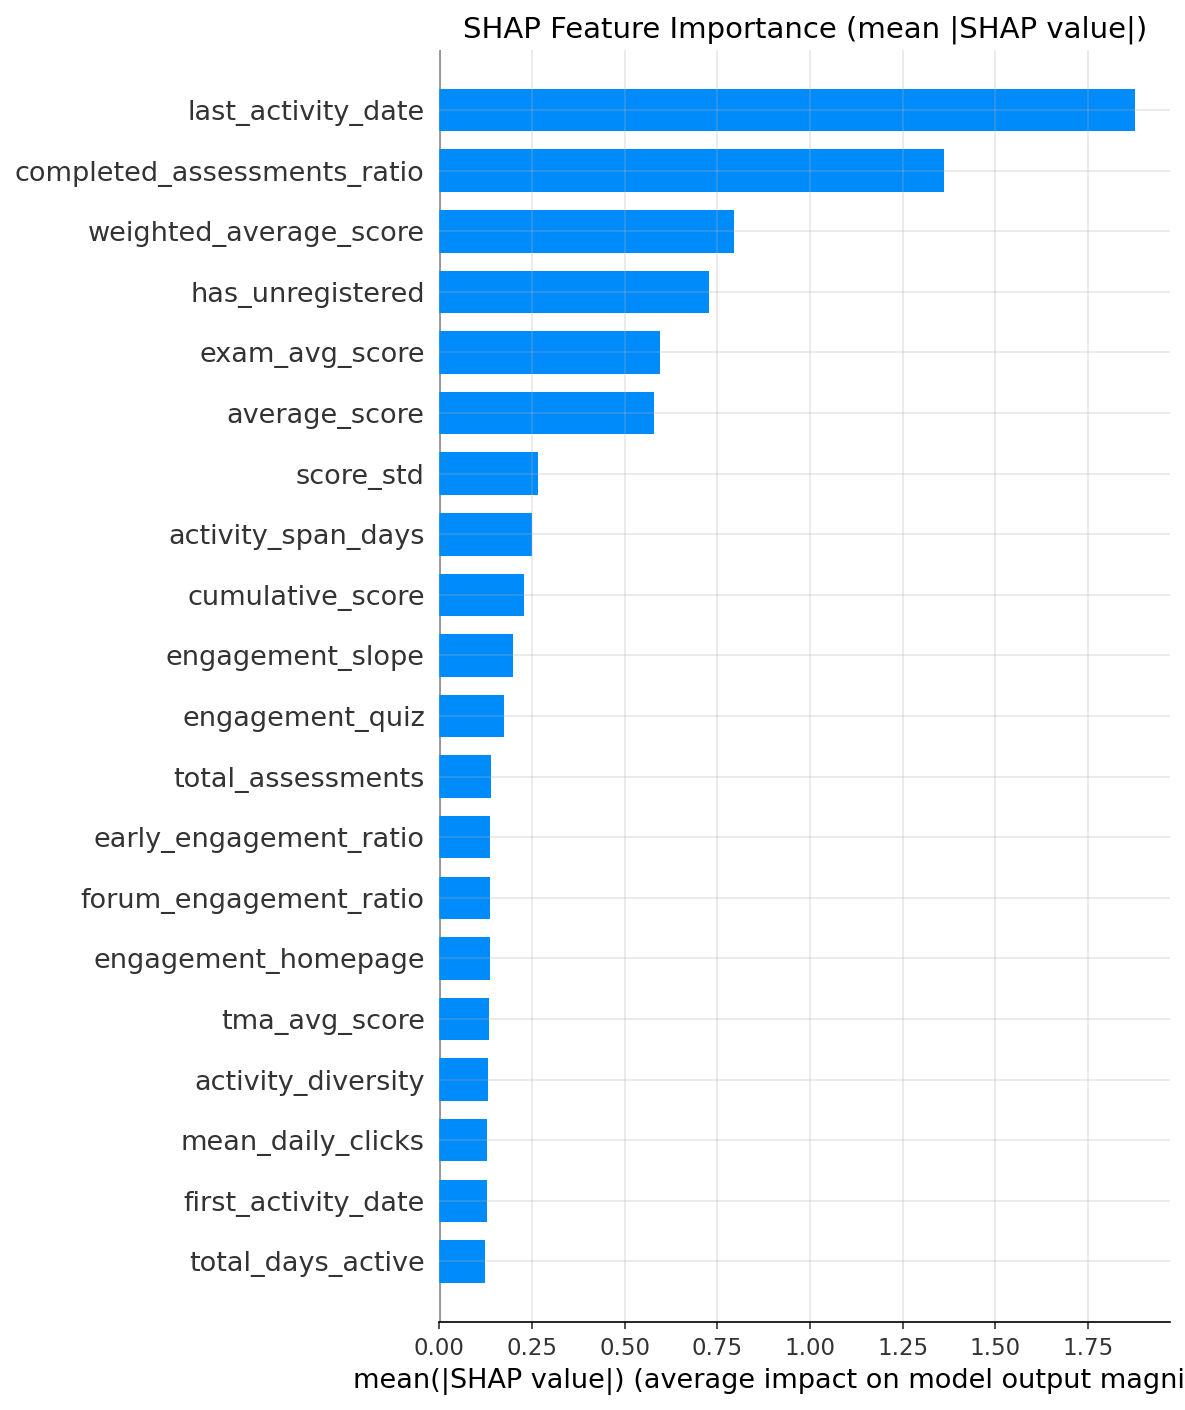

Figure saved: results/figures/shap_importance_bar.png


In [11]:
# SHAP summary plot (bar)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=model_features,
    plot_type='bar',
    show=False,
    max_display=20,
)
plt.title('SHAP Feature Importance (mean |SHAP value|)')
plt.tight_layout()
plt.savefig('../results/figures/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: results/figures/shap_importance_bar.png')

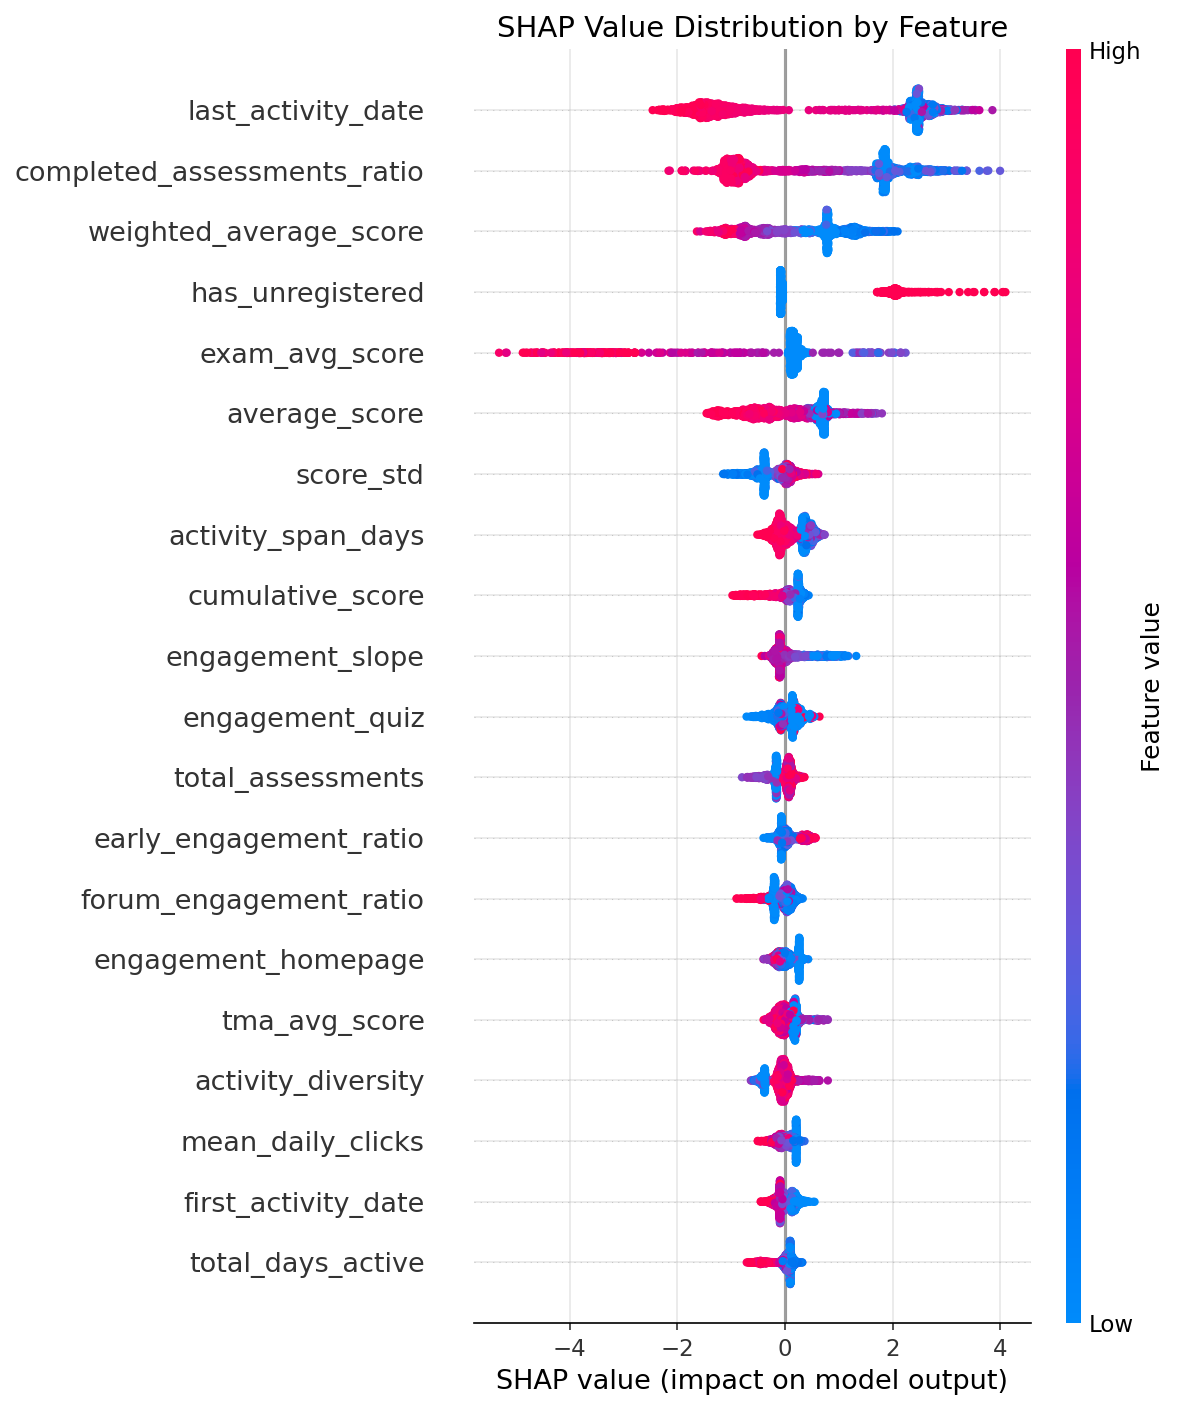

Figure saved: results/figures/shap_beeswarm.png


In [12]:
# SHAP summary plot (beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=model_features,
    show=False,
    max_display=20,
)
plt.title('SHAP Value Distribution by Feature')
plt.tight_layout()
plt.savefig('../results/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: results/figures/shap_beeswarm.png')

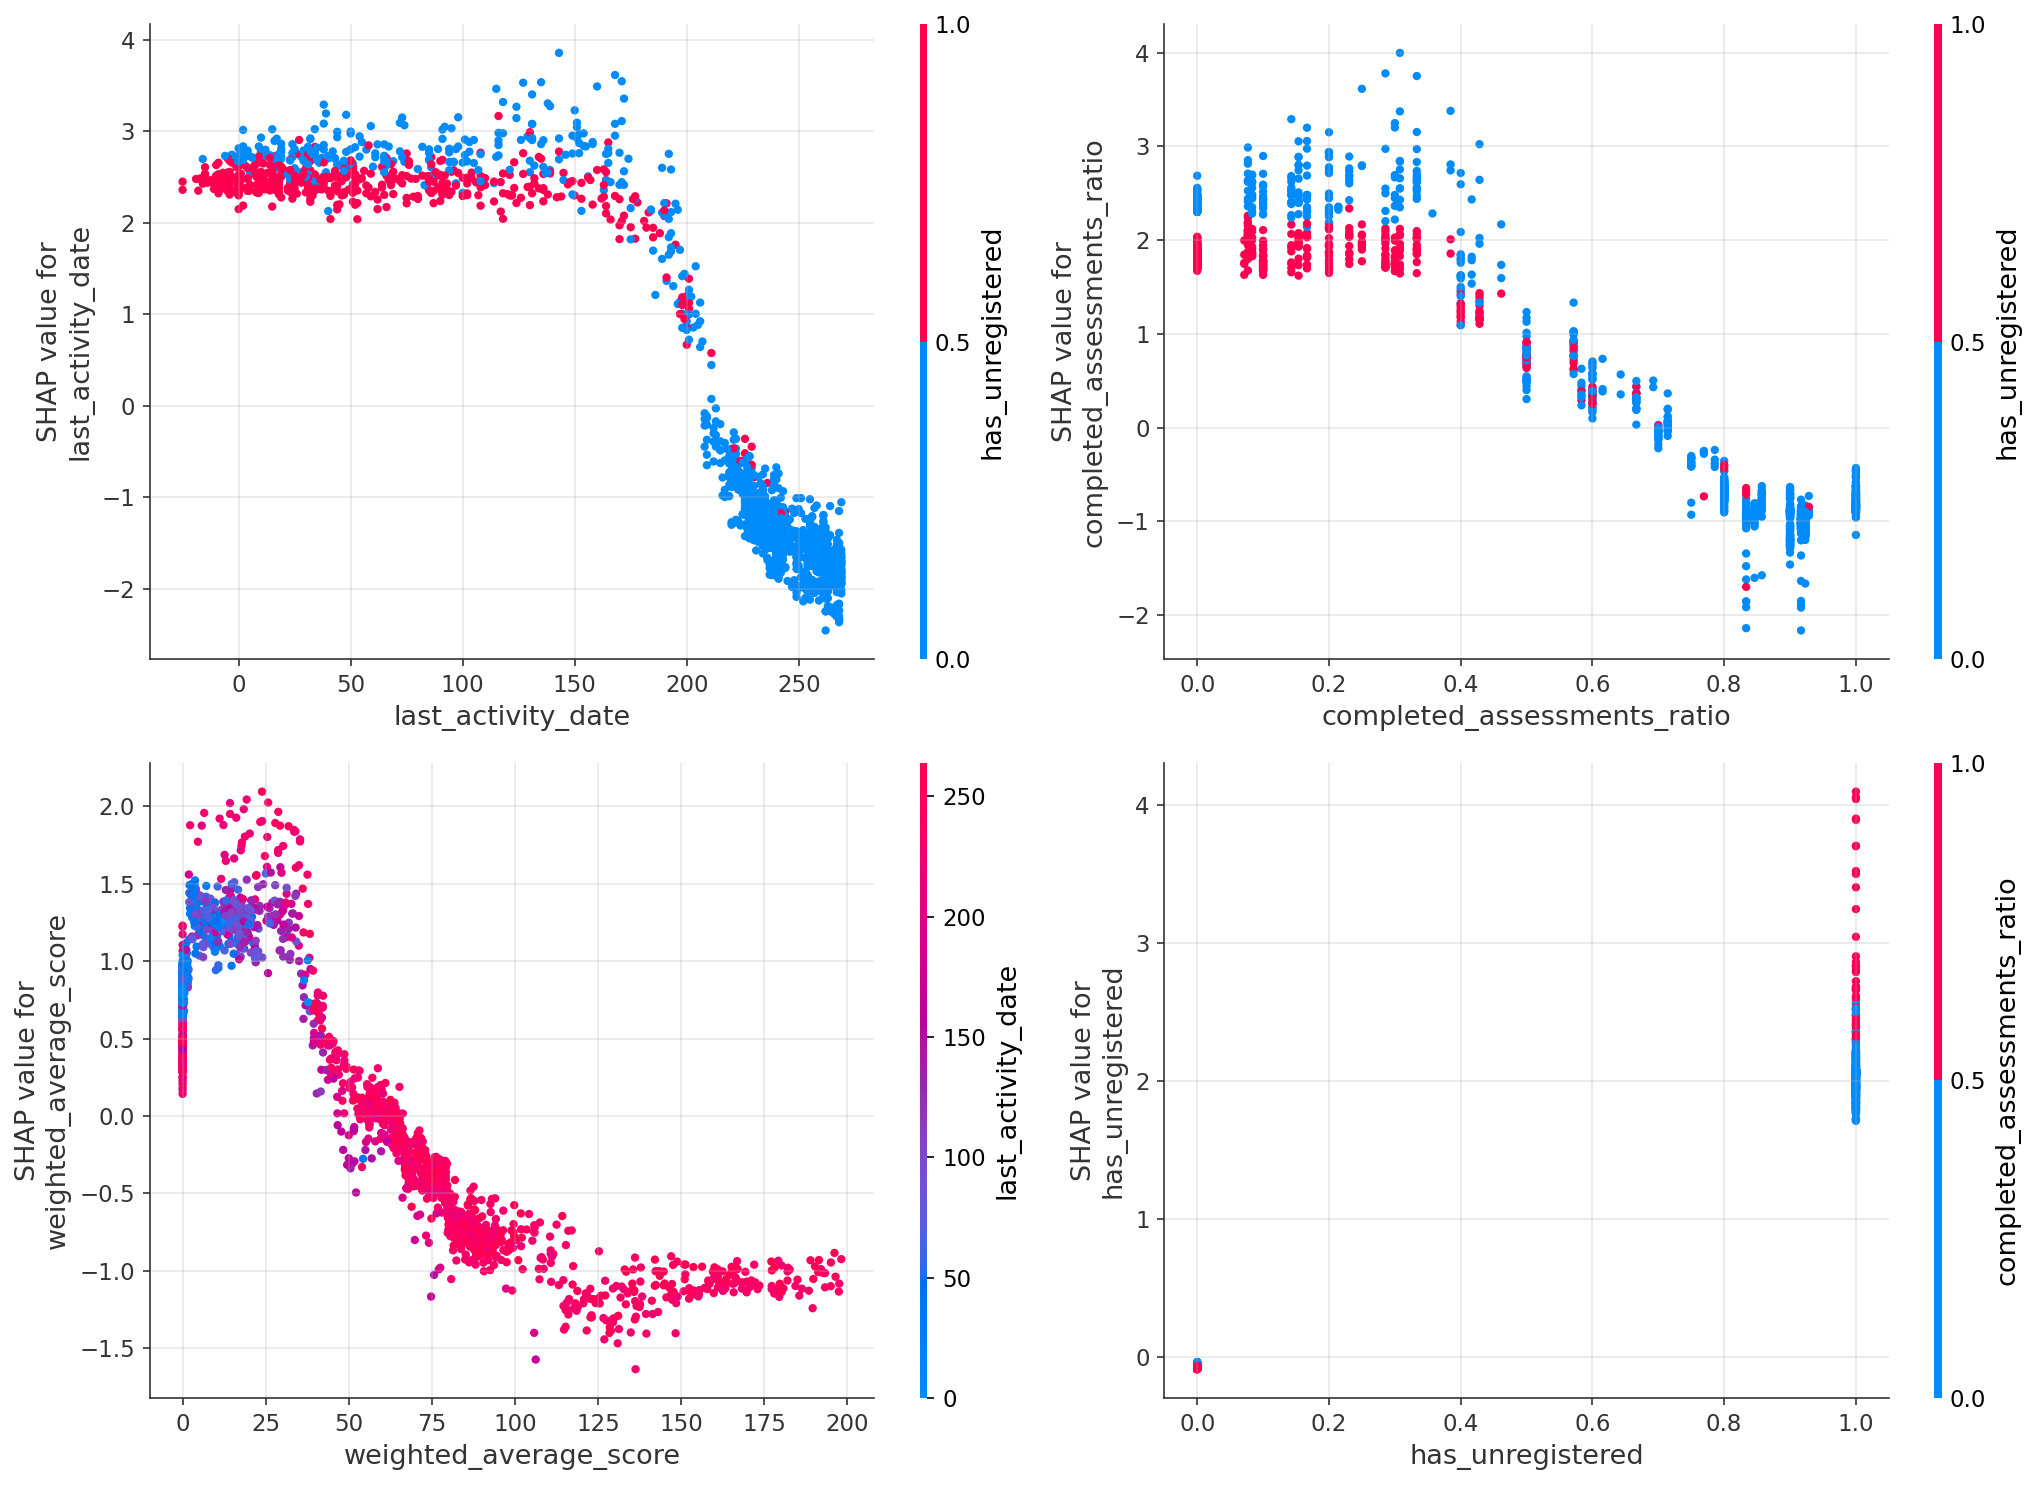

Figure saved: results/figures/shap_dependence.png


In [13]:
# SHAP dependence plots for top features
top_features_idx = np.argsort(-np.abs(shap_values).mean(axis=0))[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, idx in zip(axes.flatten(), top_features_idx):
    shap.dependence_plot(
        idx, shap_values, X_sample,
        feature_names=model_features,
        ax=ax, show=False,
    )
plt.tight_layout()
plt.savefig('../results/figures/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: results/figures/shap_dependence.png')

Example dropout student (index 1, P(dropout)=1.000):


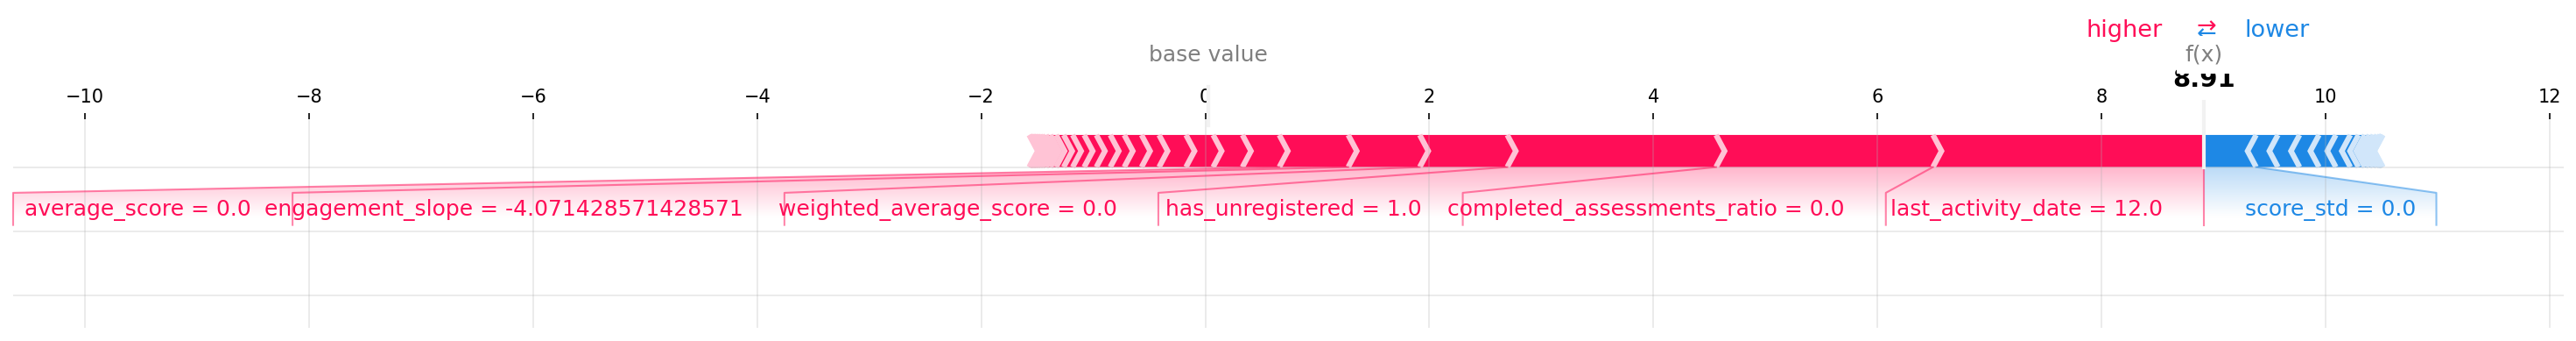


Example completed student (index 0, P(dropout)=0.005):


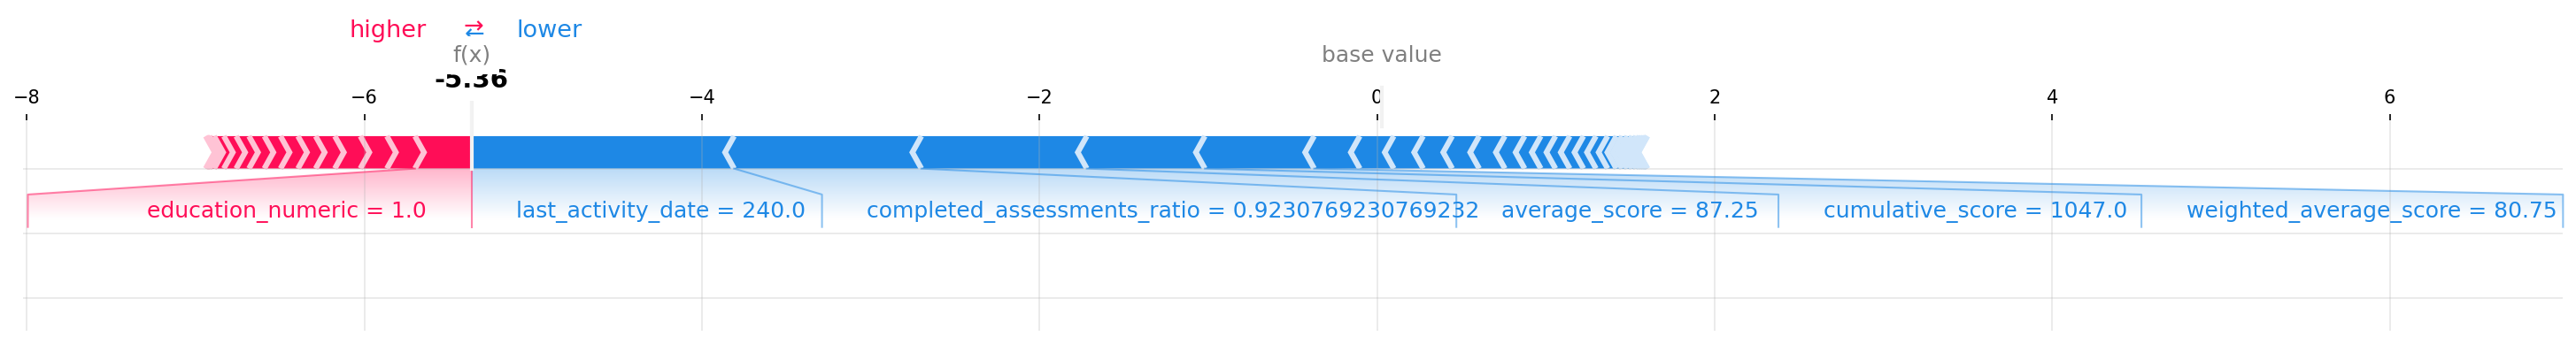

In [14]:
# Individual prediction explanations
# Show one correctly predicted dropout and one correctly predicted completion
y_prob_sample = model.predict_proba(X_sample)[:, 1]
y_true_sample = y_test[:sample_size]

# Find a high-confidence correct dropout prediction
dropout_mask = (y_true_sample == 1) & (y_prob_sample > 0.8)
if dropout_mask.any():
    dropout_idx = np.where(dropout_mask)[0][0]
    print(f'Example dropout student (index {dropout_idx}, P(dropout)={y_prob_sample[dropout_idx]:.3f}):')
    shap.force_plot(
        explainer.expected_value, shap_values[dropout_idx],
        X_sample[dropout_idx], feature_names=model_features,
        matplotlib=True, show=False,
    )
    plt.tight_layout()
    plt.savefig('../results/figures/shap_force_dropout.png', dpi=150, bbox_inches='tight')
    plt.show()

# Find a high-confidence correct completion prediction
complete_mask = (y_true_sample == 0) & (y_prob_sample < 0.2)
if complete_mask.any():
    complete_idx = np.where(complete_mask)[0][0]
    print(f'\nExample completed student (index {complete_idx}, P(dropout)={y_prob_sample[complete_idx]:.3f}):')
    shap.force_plot(
        explainer.expected_value, shap_values[complete_idx],
        X_sample[complete_idx], feature_names=model_features,
        matplotlib=True, show=False,
    )
    plt.tight_layout()
    plt.savefig('../results/figures/shap_force_completed.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4.2 Temporal Engagement Patterns

Cluster students by their weekly engagement trajectories to identify
distinct behavioral profiles.

In [15]:
# Extract weekly features
week_cols = [c for c in features.columns if c.startswith('week_') and c.endswith('_clicks')]
week_cols = sorted(week_cols)

if len(week_cols) >= 2:
    weekly_data = features[week_cols].fillna(0).values
    
    # Normalize per student (relative engagement)
    row_sums = weekly_data.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    weekly_normalized = weekly_data / row_sums
    
    # K-Means clustering on engagement trajectories
    n_clusters = 4
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(weekly_normalized)
    features['engagement_cluster'] = clusters
    
    print(f'Clustered {len(features):,} students into {n_clusters} engagement profiles.')
    for c in range(n_clusters):
        mask = clusters == c
        dropout_rate = features.loc[mask, 'is_dropout'].mean()
        print(f'  Cluster {c}: {mask.sum():,} students, '
              f'dropout rate = {dropout_rate:.1%}')
else:
    print('Weekly features not available. Skipping temporal clustering.')

Clustered 32,593 students into 4 engagement profiles.
  Cluster 0: 7,378 students, dropout rate = 49.6%
  Cluster 1: 12,875 students, dropout rate = 59.1%
  Cluster 2: 6,014 students, dropout rate = 45.0%
  Cluster 3: 6,326 students, dropout rate = 51.1%


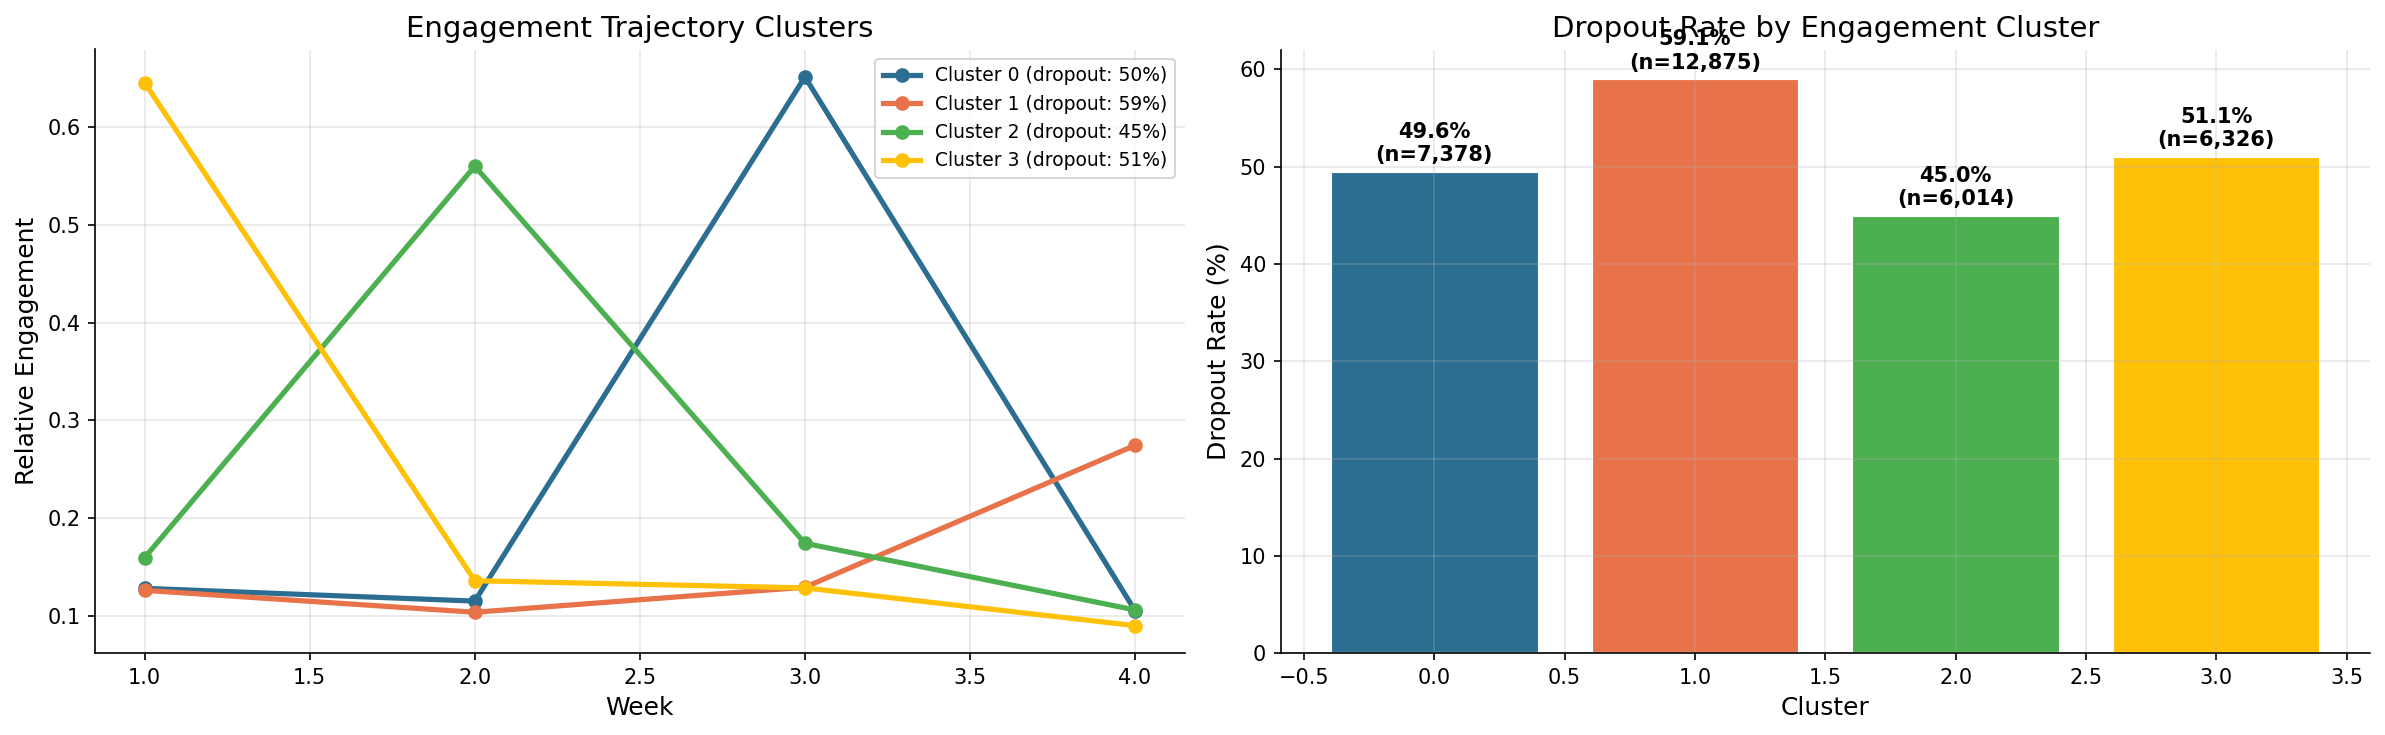

Figure saved: results/figures/temporal_clusters.png


In [16]:
# Visualize engagement trajectories by cluster
if len(week_cols) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Cluster centroids
    ax = axes[0]
    cluster_colors = [COLORS['primary'], COLORS['secondary'],
                      COLORS['success'], COLORS['warning']]
    for c in range(n_clusters):
        centroid = kmeans.cluster_centers_[c]
        dropout_rate = features.loc[clusters == c, 'is_dropout'].mean()
        ax.plot(range(1, len(week_cols) + 1), centroid,
                marker='o', linewidth=2.5, color=cluster_colors[c],
                label=f'Cluster {c} (dropout: {dropout_rate:.0%})')
    ax.set_xlabel('Week')
    ax.set_ylabel('Relative Engagement')
    ax.set_title('Engagement Trajectory Clusters')
    ax.legend(fontsize=9)
    
    # Dropout rate by cluster
    ax = axes[1]
    cluster_stats = features.groupby('engagement_cluster')['is_dropout'].agg(['mean', 'count'])
    bars = ax.bar(range(n_clusters), cluster_stats['mean'] * 100,
                  color=cluster_colors, edgecolor='white', linewidth=1.5)
    for bar, (_, row) in zip(bars, cluster_stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{row["mean"]*100:.1f}%\n(n={int(row["count"]):,})',
                ha='center', fontsize=10, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Dropout Rate (%)')
    ax.set_title('Dropout Rate by Engagement Cluster')
    
    plt.tight_layout()
    plt.savefig('../results/figures/temporal_clusters.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved: results/figures/temporal_clusters.png')

## 4.3 Cohort Segmentation

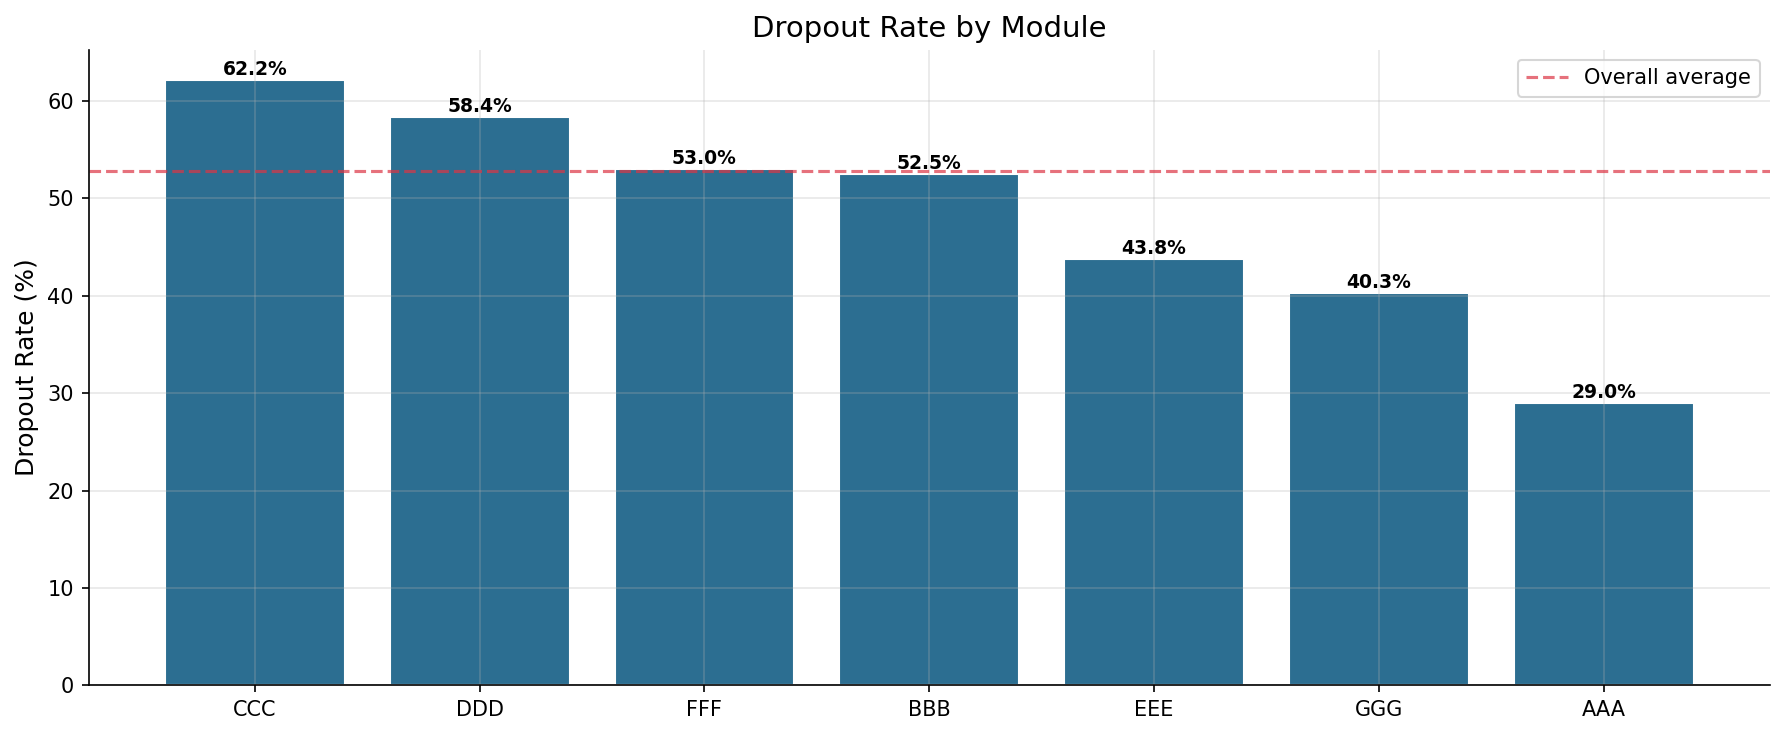

Figure saved: results/figures/dropout_by_module.png


In [17]:
# Dropout rate by module
if 'code_module' in features.columns:
    module_stats = features.groupby('code_module')['is_dropout'].agg(['mean', 'count'])
    module_stats = module_stats.sort_values('mean', ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(module_stats.index, module_stats['mean'] * 100,
                  color=COLORS['primary'], edgecolor='white', linewidth=1)
    for bar, (_, row) in zip(bars, module_stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{row["mean"]*100:.1f}%',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_ylabel('Dropout Rate (%)')
    ax.set_title('Dropout Rate by Module')
    ax.axhline(y=features['is_dropout'].mean() * 100, color=COLORS['danger'],
               linestyle='--', alpha=0.7, label='Overall average')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../results/figures/dropout_by_module.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved: results/figures/dropout_by_module.png')

In [18]:
# Model performance by subgroup
features_test = features.iloc[-len(y_test):].copy()
features_test['y_true'] = y_test
features_test['y_prob'] = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score

print('Model performance by subgroup:')
print(f'{"Subgroup":40s} {"n":>7s} {"AUC":>7s} {"Dropout%":>9s}')
print('-' * 65)

if 'gender' in features_test.columns:
    for gender in features_test['gender'].unique():
        mask = features_test['gender'] == gender
        if mask.sum() > 50:
            sub_auc = roc_auc_score(
                features_test.loc[mask, 'y_true'],
                features_test.loc[mask, 'y_prob']
            )
            dropout_pct = features_test.loc[mask, 'y_true'].mean() * 100
            print(f'  Gender: {gender:30s} {mask.sum():7,} {sub_auc:7.4f} {dropout_pct:8.1f}%')

if 'age_band' in features_test.columns:
    for age in features_test['age_band'].unique():
        mask = features_test['age_band'] == age
        if mask.sum() > 50:
            sub_auc = roc_auc_score(
                features_test.loc[mask, 'y_true'],
                features_test.loc[mask, 'y_prob']
            )
            dropout_pct = features_test.loc[mask, 'y_true'].mean() * 100
            print(f'  Age: {age:32s} {mask.sum():7,} {sub_auc:7.4f} {dropout_pct:8.1f}%')

Model performance by subgroup:
Subgroup                                       n     AUC  Dropout%
-----------------------------------------------------------------
  Gender: M                                3,745  0.9898     53.1%
  Gender: F                                2,774  0.9895     52.4%
  Age: 0-35                               4,492  0.9894     53.0%
  Age: 35-55                              2,004  0.9900     52.4%


## 4.4 Early Warning Threshold Analysis

Analyze the trade-off between false positive rate and early detection
capability at different classification thresholds.

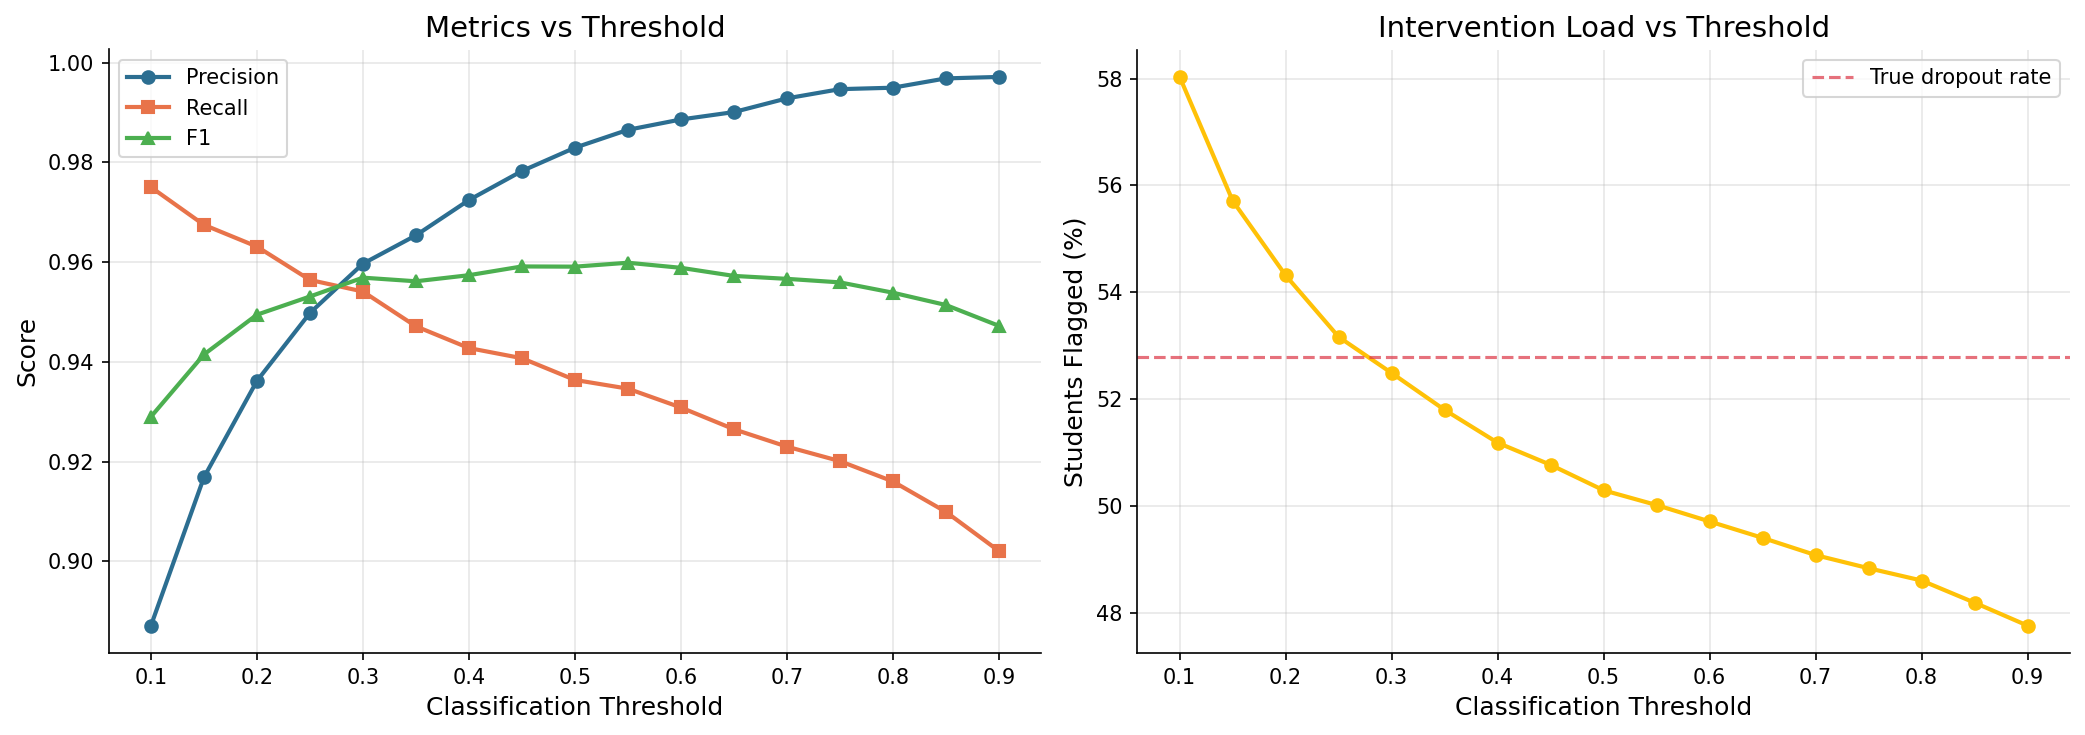

Figure saved: results/figures/threshold_analysis.png


In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.95, 0.05)
threshold_results = []

y_prob_test = model.predict_proba(X_test)[:, 1]

for t in thresholds:
    preds = (y_prob_test >= t).astype(int)
    threshold_results.append({
        'threshold': t,
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall': recall_score(y_test, preds, zero_division=0),
        'f1': f1_score(y_test, preds, zero_division=0),
        'flagged_pct': preds.mean() * 100,
    })

tr_df = pd.DataFrame(threshold_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision / Recall / F1 vs threshold
ax = axes[0]
ax.plot(tr_df['threshold'], tr_df['precision'], marker='o', label='Precision',
        color=COLORS['primary'], linewidth=2)
ax.plot(tr_df['threshold'], tr_df['recall'], marker='s', label='Recall',
        color=COLORS['secondary'], linewidth=2)
ax.plot(tr_df['threshold'], tr_df['f1'], marker='^', label='F1',
        color=COLORS['success'], linewidth=2)
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

# Students flagged vs threshold
ax = axes[1]
ax.plot(tr_df['threshold'], tr_df['flagged_pct'], marker='o',
        color=COLORS['warning'], linewidth=2)
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Students Flagged (%)')
ax.set_title('Intervention Load vs Threshold')
ax.axhline(y=y_test.mean() * 100, color=COLORS['danger'],
           linestyle='--', alpha=0.7, label='True dropout rate')
ax.legend()

plt.tight_layout()
plt.savefig('../results/figures/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: results/figures/threshold_analysis.png')

## 4.5 Save Advanced Analysis Results

In [21]:
# Save SHAP importance ranking
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=model_features
).sort_values(ascending=False)

shap_importance.to_csv('../results/reports/shap_importance.csv')
print('SHAP importance saved: results/reports/shap_importance.csv')

# Save threshold analysis
tr_df.to_csv('../results/reports/threshold_analysis.csv', index=False)
print('Threshold analysis saved: results/reports/threshold_analysis.csv')

SHAP importance saved: results/reports/shap_importance.csv
Threshold analysis saved: results/reports/threshold_analysis.csv


## Summary

Key findings from advanced analysis:

1. SHAP analysis confirms that assessment completion and VLE engagement
   are the primary drivers, but also reveals non-linear interaction
   effects between features.

2. Temporal clustering identifies distinct engagement profiles:
   early disengagement, gradual decline, consistent engagement,
   and front-loaded effort.

3. Model performance varies by subgroup, suggesting potential for
   fairness-aware calibration in deployment.

4. Threshold analysis shows that a threshold of approximately 0.4
   maximizes F1-score, while lower thresholds (0.3) favor recall
   for early intervention scenarios.

Next notebook: NLP-augmented hybrid prediction model.